# LightGBM Stage 2 — Evaluation Notebook

Reads everything **directly from S3** (`s3://thesis-data-ismaktam/lgbm/`) — no manual `aws s3 sync` step. Files are cached under `results/lgbm/` after first download.

Predictions run on **CPU multi-thread** via native `lgb.Booster.predict()` — for a single batch eval on a many-core box this beats GPU FIL (which has per-call save_model + load overhead).

```
s3://thesis-data-ismaktam/lgbm/
  fold_assignment.parquet
  kfold/
    fold{0..4}_features.parquet
    fold{0..4}_models.joblib
    cv_results.json
```

**Fold assignment** is pulled from `fold_assignment.parquet` — folds are 100 % identical to training.

## 0. Imports

In [1]:
import sys, os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import joblib
import properscoring as ps
import boto3
from botocore.exceptions import ClientError

warnings.filterwarnings('ignore')

ROOT = Path('../..')
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.transforms import ProjectionTransform, IndicatorTransform
from thesis.transforms.pipeline import TransformPipeline
from thesis.scripts.run_grk_kfold_cv import SOIL_VARS

print(f'Working directory: {Path.cwd()}')
print(f'LightGBM:          {lgb.__version__}')
print(f'CPU threads:       {os.cpu_count()}')

Working directory: /root/precip_interpolation_thesis
LightGBM:          4.5.0
CPU threads:       48


## 1. S3 Source + Local Cache

All artefacts live under `s3://thesis-data-ismaktam/lgbm/`. They are downloaded on first access and cached locally in `results/lgbm/` — re-runs are instant.

In [2]:
# ── S3 source ────────────────────────────────────────────────────────────────
S3_BUCKET    = 'thesis-data-ismaktam'
S3_LGBM_ROOT = 'lgbm'
S3_KFOLD     = f'{S3_LGBM_ROOT}/kfold'

# ── Local cache (downloads land here once, then reused) ──────────────────────
CACHE_DIR = Path('results/lgbm')
KFOLD_DIR = CACHE_DIR / 'kfold'
FIG_DIR   = Path('outputs/lgbm_eval')
for d in (CACHE_DIR, KFOLD_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── Constants ────────────────────────────────────────────────────────────────
K_FOLDS    = 5
TARGET_COL = 'precip_mm'

# ── S3 helper ────────────────────────────────────────────────────────────────
s3 = boto3.client('s3')

def s3_get(key: str, local: Path, force: bool = False) -> Path:
    """Download s3://{bucket}/{key} → local path if missing, return local."""
    if local.exists() and not force:
        return local
    local.parent.mkdir(parents=True, exist_ok=True)
    try:
        s3.download_file(S3_BUCKET, key, str(local))
        print(f'  ↓ {key}  ({local.stat().st_size / 1e6:.1f} MB)')
    except ClientError as e:
        raise FileNotFoundError(f's3://{S3_BUCKET}/{key} not found ({e})') from e
    return local

print(f'S3 source: s3://{S3_BUCKET}/{S3_LGBM_ROOT}/')
print(f'Cache dir: {CACHE_DIR}/')

S3 source: s3://thesis-data-ismaktam/lgbm/
Cache dir: results/lgbm/


## 2. Download Everything + Load Models

One cell that does **all** the slow IO upfront:

1. Pulls every artefact from S3 (cached after first run)
2. Loads the 5 fold model files into memory as `FOLD_MODELS[fold_id]`
3. Reads `fold_assignment.parquet` and `cv_results.json` into DataFrames
4. Recovers `FEATURE_COLS` and `QUANTILES` from fold-0 metadata

After this cell finishes, every following cell only does in-memory work.

In [5]:
print('Downloading artefacts ...')
s3_get(f'{S3_LGBM_ROOT}/fold_assignment.parquet', CACHE_DIR / 'fold_assignment.parquet')
s3_get(f'{S3_KFOLD}/cv_results.json',             KFOLD_DIR / 'cv_results.json')
for i in range(K_FOLDS):
    s3_get(f'{S3_KFOLD}/fold{i}_features.parquet', KFOLD_DIR / f'fold{i}_features.parquet')
    s3_get(f'{S3_KFOLD}/fold{i}_models.joblib',    KFOLD_DIR / f'fold{i}_models.joblib')

print('\nLoading models into memory ...')
FOLD_MODELS = {
    i: joblib.load(KFOLD_DIR / f'fold{i}_models.joblib')
    for i in range(K_FOLDS)
}
FEATURE_COLS = FOLD_MODELS[0]['feature_cols']
QUANTILES    = FOLD_MODELS[0]['quantiles']

df_folds = pd.read_parquet(CACHE_DIR / 'fold_assignment.parquet')
with open(KFOLD_DIR / 'cv_results.json') as f:
    cv_json = json.load(f)
df_json = pd.DataFrame(cv_json).set_index('fold')

OK_BASELINE = None
try:
    obj = s3.get_object(Bucket=S3_BUCKET, Key='kriging/kfold/cv_results.json')
    ok = json.loads(obj['Body'].read())
    OK_BASELINE = {
        'crps_mm':    ok['summary']['crps_mm_mean'],
        'mae_mm':     ok['summary']['mae_mm_mean'],
        'best_combo': ok['summary'].get('best_combo'),
    }
except ClientError:
    pass

print(f'\n{K_FOLDS} folds × {len(QUANTILES)} quantile boosters loaded')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS[:6]} ... +{len(FEATURE_COLS)-6} more')
print(f'Quantiles: {QUANTILES}')
print(f'Fold sizes: {df_folds["fold"].value_counts().sort_index().to_dict()}')
print(f'OK baseline:  {"loaded" if OK_BASELINE else "not in S3 yet"}')


Loading models into memory ...



5 folds × 11 quantile boosters loaded
Features (32): ['x_proj', 'y_proj', 'elevation_m', 'idw', 'gos', 'svd_00'] ... +26 more
Quantiles: [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
Fold sizes: {0: 394, 1: 393, 2: 393, 3: 393, 4: 393}
OK baseline:  not in S3 yet


## 2. Load Station Data

In [4]:
cfg      = Config()
registry = DataRegistry.from_config(cfg)

print(f'Date range: {cfg.date_start} → {cfg.date_end}')
print('Loading station data ...')

all_raw  = registry.stations.load(cfg.date_start, cfg.date_end)
pipeline = TransformPipeline([
    ProjectionTransform(target_crs=cfg.study_area.target_crs),
    IndicatorTransform(threshold_mm=cfg.wet_day_threshold_mm),
])
all_proc = pipeline.fit_transform(all_raw)
df_wet   = all_proc[all_proc['rain_indicator'] == 1].copy()

station_meta = (
    all_proc
    .drop_duplicates('station_id')[['station_id', 'x_proj', 'y_proj', 'elevation_m']]
    .reset_index(drop=True)
)

print(f'Wet records:  {len(df_wet):,}')
print(f'Stations:     {len(station_meta):,}')

Date range: 1961-01-01 → 2023-12-31
Loading station data ...
Wet records:  17,409,376
Stations:     1,966


## 3. SoilGrids

In [10]:
soil_rows = {'station_id': station_meta['station_id'].values}
for var, src in registry.soilgrids.items():
    if var in SOIL_VARS:
        soil_rows[var] = src.sample_at_projected(
            station_meta['x_proj'].values,
            station_meta['y_proj'].values,
        )

soil_static    = pd.DataFrame(soil_rows).set_index('station_id')
available_soil = [v for v in SOIL_VARS if v in soil_static.columns]
for v in available_soil:
    soil_static[v] = soil_static[v].fillna(float(soil_static[v].median()))

print(f'SoilGrids: {available_soil}')

SoilGrids: ['bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa']


## 4. Merge Fold Assignment

`df_folds` is already in memory from §2 — just merge it into `df_wet` so every wet record carries its fold id.

In [11]:
df_wet = df_wet.merge(df_folds[['station_id', 'fold']], on='station_id', how='left')
n_missing = df_wet['fold'].isna().sum()
if n_missing > 0:
    print(f'WARNING: {n_missing} wet records have no fold — station set mismatch!')
else:
    print(f'Fold assignment merged: {len(df_wet):,} wet records, all assigned')

Fold assignment merged: 17,409,376 wet records, all assigned


## 5. Out-of-Fold Predictions

Everything is already in memory from §2. For each fold:

1. grab the booster bundle from `FOLD_MODELS[fold_id]` and read `fold{i}_features.parquet` from disk cache
2. build the test-fold feature matrix (only stations with `fold == fold_id`)
3. for every quantile booster: `Booster.predict(num_iteration=best_iter, n_jobs=N_THREADS)` — LightGBM's own multi-threaded C++ path
4. clip to ≥ 0, sort along the quantile axis to enforce monotonicity, score with `properscoring.crps_ensemble`

In [12]:
import time

N_THREADS = os.cpu_count()
all_preds = []
print(f'Predict backend: CPU multi-thread ({N_THREADS} cores)')

for fold_id in range(K_FOLDS):
    t0     = time.time()
    saved  = FOLD_MODELS[fold_id]
    df_geo = pd.read_parquet(KFOLD_DIR / f'fold{fold_id}_features.parquet')

    df_fold = (
        df_wet[['station_id', 'date', 'precip_mm', 'fold',
                'x_proj', 'y_proj', 'elevation_m']]
        .merge(df_geo, on=['station_id', 'date'], how='inner')
        .merge(soil_static[available_soil].reset_index(),
               on='station_id', how='left')
    )
    for v in available_soil:
        df_fold[v] = df_fold[v].fillna(df_fold[v].median())

    df_test = df_fold[df_fold['fold'] == fold_id].copy()
    X_te    = np.ascontiguousarray(
        df_test[FEATURE_COLS].values.astype(np.float32)
    )
    y_te    = df_test[TARGET_COL].values.astype(np.float32)
    del df_geo, df_fold

    boosters   = saved['models']
    best_iters = saved.get('best_iterations', {})
    n, K       = len(X_te), len(QUANTILES)
    q_preds    = np.empty((n, K), dtype=np.float32)
    for qi, alpha in enumerate(QUANTILES):
        q_preds[:, qi] = boosters[alpha].predict(
            X_te,
            num_iteration=best_iters.get(alpha, -1),
            n_jobs=N_THREADS,
        ).astype(np.float32)
    np.clip(q_preds, 0.0, None, out=q_preds)
    q_preds.sort(axis=1)

    df_out = df_test[['station_id', 'date', 'precip_mm',
                      'x_proj', 'y_proj', 'fold']].copy()
    df_out['q50']   = q_preds[:, QUANTILES.index(0.50)]
    df_out['error'] = df_out['q50'] - df_out['precip_mm']
    df_out['crps']  = ps.crps_ensemble(y_te, q_preds)
    for qi, alpha in enumerate(QUANTILES):
        df_out[f'q{int(alpha * 100):02d}'] = q_preds[:, qi]

    crps = df_out['crps'].mean()
    mae  = df_out['error'].abs().mean()
    print(f'Fold {fold_id}: n={len(df_out):,}  CRPS={crps:.4f}  MAE={mae:.4f}  '
          f'({time.time() - t0:.1f}s)')
    all_preds.append(df_out)
    del X_te, y_te, q_preds, df_test, df_out

df_all = pd.concat(all_preds, ignore_index=True)
print(f'\nTotal OOF records: {len(df_all):,}')

Predict backend: CPU multi-thread (48 cores)
Fold 0: n=3,520,827  CRPS=0.8039  MAE=1.0663  (108.7s)
Fold 1: n=3,466,145  CRPS=0.7962  MAE=1.0556  (110.3s)
Fold 2: n=3,495,450  CRPS=0.7871  MAE=1.0400  (105.2s)
Fold 3: n=3,471,152  CRPS=0.7742  MAE=1.0228  (109.4s)
Fold 4: n=3,452,880  CRPS=0.7769  MAE=1.0239  (103.2s)

Total OOF records: 17,406,454


## 6. CV Metrics — JSON vs Recomputed

`cv_results.json` (the metrics persisted during training) and `OK_BASELINE` were both pulled in §2 — we just consume them here. Recomputed CRPS/MAE should match the stored JSON within a few decimals.

The hardcoded *0.7895 / 0.790* "Tweedie baseline" that used to live here was methodologically invalid (single-split point model). The real OK k-fold baseline is loaded from `s3://thesis-data-ismaktam/kriging/kfold/cv_results.json` once `run_cv_kfold_kriging.py` finishes; otherwise we just skip the comparison.

In [13]:
rows = []
for fold_id in range(K_FOLDS):
    sub  = df_all[df_all['fold'] == fold_id]
    crps = sub['crps'].mean()
    mae  = sub['error'].abs().mean()
    rmse = np.sqrt((sub['error'] ** 2).mean())
    rows.append({'fold': fold_id, 'crps': crps, 'mae': mae, 'rmse': rmse})
df_recomp = pd.DataFrame(rows).set_index('fold')

print('=== Stored JSON vs Recomputed ===')
print(f'{"":6s} {"CRPS_json":>10s} {"CRPS_eval":>10s} {"MAE_json":>10s} {"MAE_eval":>10s}')
for fold_id in range(K_FOLDS):
    cj = df_json.loc[fold_id, 'crps']
    cr = df_recomp.loc[fold_id, 'crps']
    mj = df_json.loc[fold_id, 'mae']
    mr = df_recomp.loc[fold_id, 'mae']
    match = '✓' if abs(cj - cr) < 0.001 else '✗ MISMATCH'
    print(f'Fold {fold_id}  {cj:10.4f} {cr:10.4f} {mj:10.4f} {mr:10.4f}  {match}')

print()
summary = df_recomp.agg(['mean', 'std'])
print('=== Summary (recomputed) ===')
for col in ['crps', 'mae', 'rmse']:
    m, s = summary.loc['mean', col], summary.loc['std', col]
    print(f'  {col:<8} {m:.4f} ± {s:.4f}')

# ── OK k-fold baseline (already loaded in §2) ────────────────────────────────
print()
if OK_BASELINE is None:
    print('OK k-fold baseline:  NOT in S3 yet (run run_cv_kfold_kriging.py to produce it)')
else:
    crps_mean = summary.loc['mean', 'crps']
    mae_mean  = summary.loc['mean', 'mae']
    print(f'Baseline OK ({OK_BASELINE["best_combo"]}):  '
          f'CRPS={OK_BASELINE["crps_mm"]:.4f}  MAE={OK_BASELINE["mae_mm"]:.4f}')
    print(f'LGBM quantile (this run): CRPS={crps_mean:.4f}  MAE={mae_mean:.4f}')
    print(f'Improvement CRPS:         '
          f'{(OK_BASELINE["crps_mm"] - crps_mean) / OK_BASELINE["crps_mm"] * 100:+.1f}%')
    print(f'Improvement MAE:          '
          f'{(OK_BASELINE["mae_mm"]  - mae_mean ) / OK_BASELINE["mae_mm"]  * 100:+.1f}%')

=== Stored JSON vs Recomputed ===
        CRPS_json  CRPS_eval   MAE_json   MAE_eval
Fold 0      0.8039     0.8039     1.0663     1.0663  ✓
Fold 1      0.7962     0.7962     1.0556     1.0556  ✓
Fold 2      0.7871     0.7871     1.0400     1.0400  ✓
Fold 3      0.7742     0.7742     1.0228     1.0228  ✓
Fold 4      0.7769     0.7769     1.0239     1.0239  ✓

=== Summary (recomputed) ===
  crps     0.7876 ± 0.0126
  mae      1.0417 ± 0.0192
  rmse     2.1234 ± 0.0286

OK k-fold baseline:  NOT in S3 yet (run run_cv_kfold_kriging.py to produce it)


## 8. CV Metrics Bar Chart

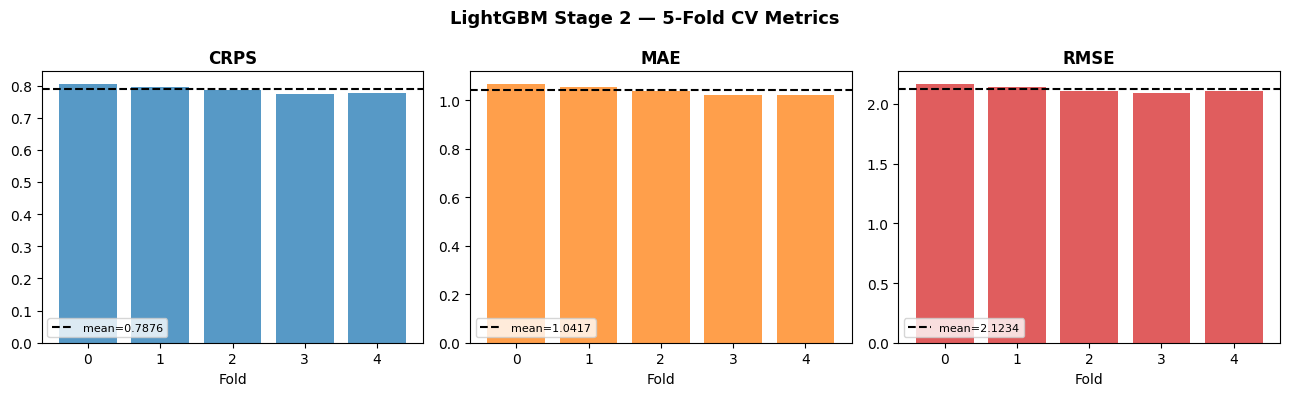

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
baselines = {
    'crps': OK_BASELINE['crps_mm'] if OK_BASELINE else None,
    'mae':  OK_BASELINE['mae_mm']  if OK_BASELINE else None,
    'rmse': None,
}
colors = {'crps': 'tab:blue', 'mae': 'tab:orange', 'rmse': 'tab:red'}

for ax, col in zip(axes, ['crps', 'mae', 'rmse']):
    vals = df_recomp[col]
    ax.bar(vals.index, vals, color=colors[col], alpha=0.75)
    ax.axhline(vals.mean(), color='black', linestyle='--', lw=1.5,
               label=f'mean={vals.mean():.4f}')
    if baselines[col] is not None:
        ax.axhline(baselines[col], color='red', linestyle=':', lw=1.5,
                   label=f'OK baseline={baselines[col]:.4f}')
    ax.set_title(col.upper(), fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_xticks(range(K_FOLDS))
    ax.legend(fontsize=8)

fig.suptitle('LightGBM Stage 2 — 5-Fold CV Metrics', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(FIG_DIR / 'cv_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Scatter: Predicted q50 vs Actual

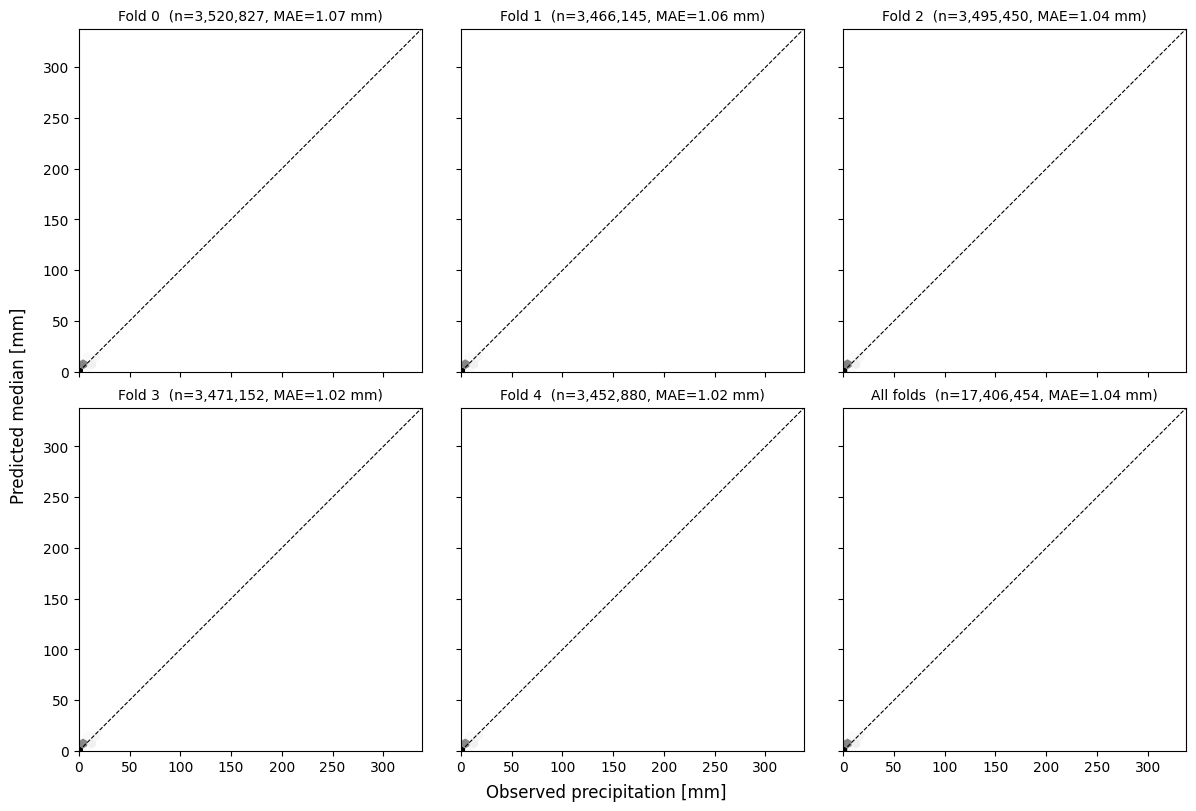

In [28]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(12, 8),
                        sharex=True, sharey=True, constrained_layout=True)

vmax = max(df_all["precip_mm"].max(), df_all["q50"].max())
lim = (0, float(np.ceil(vmax)))

for ax, k in zip(axes.flat, sorted(df_all["fold"].unique())):
    sub = df_all[df_all["fold"] == k]
    ax.hexbin(sub["precip_mm"], sub["q50"],
            gridsize=40, extent=(*lim, *lim),
            cmap="Greys", mincnt=1, linewidths=0)
    ax.plot(lim, lim, "k--", lw=0.8)
    mae = sub["error"].abs().mean()
    ax.set_title(f"Fold {k}  (n={len(sub):,}, MAE={mae:.2f} mm)", fontsize=10)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_aspect("equal")

# 6th panel = pooled across folds
ax = axes.flat[-1]
ax.hexbin(df_all["precip_mm"], df_all["q50"],
        gridsize=40, extent=(*lim, *lim),
        cmap="Greys", mincnt=1, linewidths=0)
ax.plot(lim, lim, "k--", lw=0.8)
mae = df_all["error"].abs().mean()
ax.set_title(f"All folds  (n={len(df_all):,}, MAE={mae:.2f} mm)", fontsize=10)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_aspect("equal")

fig.supxlabel("Observed precipitation [mm]")
fig.supylabel("Predicted median [mm]")
plt.show()

## 10. Quantile Calibration

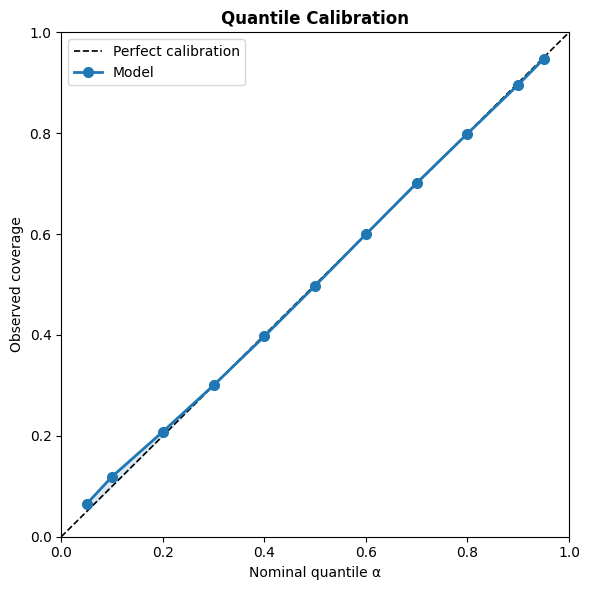

 alpha  coverage
  0.05     0.065
  0.10     0.119
  0.20     0.208
  0.30     0.300
  0.40     0.397
  0.50     0.498
  0.60     0.600
  0.70     0.701
  0.80     0.799
  0.90     0.896
  0.95     0.947


In [27]:
y_true   = df_all['precip_mm'].values
coverage = []
for alpha in QUANTILES:
    col = f'q{int(alpha * 100):02d}'
    obs_below = (y_true <= df_all[col].values).mean()
    coverage.append({'alpha': alpha, 'coverage': obs_below})
df_cal = pd.DataFrame(coverage)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')
ax.plot(df_cal['alpha'], df_cal['coverage'], 'o-',
        color='tab:blue', lw=2, ms=7, label='Model')
ax.fill_between(df_cal['alpha'], df_cal['alpha'], df_cal['coverage'],
                alpha=0.15, color='tab:blue')
ax.set_xlabel('Nominal quantile α')
ax.set_ylabel('Observed coverage')
ax.set_title('Quantile Calibration', fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.tight_layout()
plt.savefig(FIG_DIR / 'calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_cal.round(3).to_string(index=False))

## 11. CRPS & MAE by Precipitation Intensity

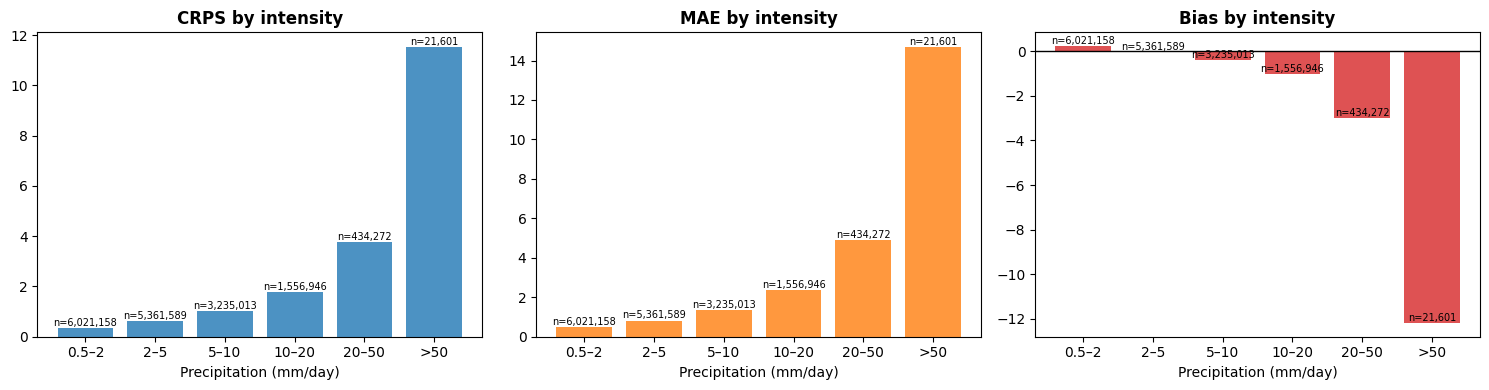

In [20]:
bins   = [0.5, 2, 5, 10, 20, 50, 200]
labels = ['0.5–2', '2–5', '5–10', '10–20', '20–50', '>50']
df_all['intensity'] = pd.cut(df_all['precip_mm'], bins=bins, labels=labels)

grp = df_all.groupby('intensity', observed=True).agg(
    crps_mean = ('crps',  'mean'),
    mae_mean  = ('error', lambda x: np.abs(x).mean()),
    bias_mean = ('error', 'mean'),
    n         = ('crps',  'count'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, color in [
    (axes[0], 'crps_mean', 'CRPS by intensity',   'tab:blue'),
    (axes[1], 'mae_mean',  'MAE by intensity',    'tab:orange'),
    (axes[2], 'bias_mean', 'Bias by intensity',   'tab:red'),
]:
    bars = ax.bar(grp['intensity'].astype(str), grp[col], color=color, alpha=0.8)
    for bar, n in zip(bars, grp['n']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'n={n:,}', ha='center', va='bottom', fontsize=7)
    if col == 'bias_mean':
        ax.axhline(0, color='black', lw=1)
    ax.set_xlabel('Precipitation (mm/day)')
    ax.set_title(title, fontweight='bold')

fig.tight_layout()
plt.savefig(FIG_DIR / 'metrics_by_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Spatial Error Map (MAE / Bias / CRPS per station)

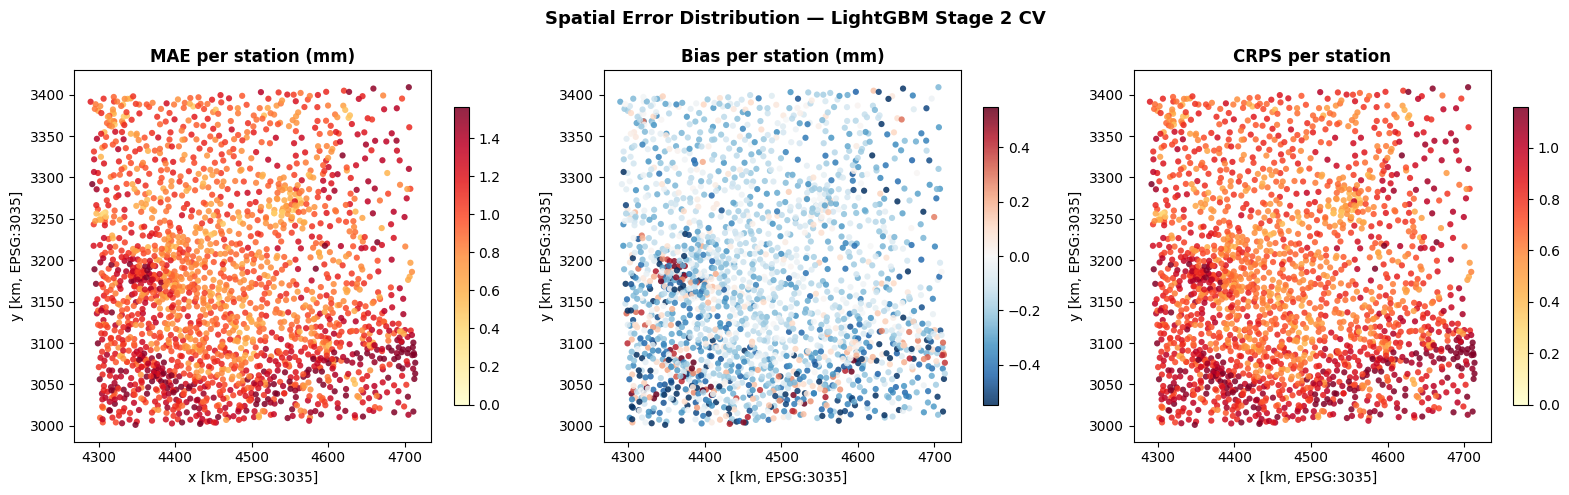

In [21]:
station_err = df_all.groupby('station_id').agg(
    mae  = ('error', lambda x: np.abs(x).mean()),
    bias = ('error', 'mean'),
    crps = ('crps',  'mean'),
    n    = ('error', 'count'),
    x    = ('x_proj', 'first'),
    y    = ('y_proj', 'first'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title, cmap in [
    (axes[0], 'mae',  'MAE per station (mm)',  'YlOrRd'),
    (axes[1], 'bias', 'Bias per station (mm)', 'RdBu_r'),
    (axes[2], 'crps', 'CRPS per station',      'YlOrRd'),
]:
    vmax = np.percentile(np.abs(station_err[col]), 95)
    vmin = -vmax if col == 'bias' else 0
    sc = ax.scatter(
        station_err['x'] / 1000, station_err['y'] / 1000,
        c=station_err[col], cmap=cmap, vmin=vmin, vmax=vmax,
        s=20, alpha=0.85, edgecolors='none',
    )
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('x [km, EPSG:3035]')
    ax.set_ylabel('y [km, EPSG:3035]')

fig.suptitle('Spatial Error Distribution — LightGBM Stage 2 CV',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(FIG_DIR / 'spatial_error.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. 90 % Prediction Interval Coverage

90% PI coverage:    0.897  (target 0.90)
Mean interval width: 4.567 mm


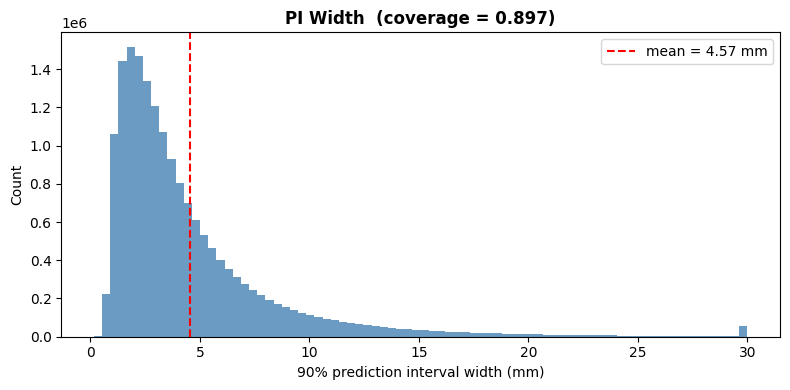

In [23]:
df_all['pi_width'] = df_all['q95'] - df_all['q05']
df_all['covered']  = (
    (df_all['precip_mm'] >= df_all['q05']) &
    (df_all['precip_mm'] <= df_all['q95'])
)

cov   = df_all['covered'].mean()
width = df_all['pi_width'].mean()
print(f'90% PI coverage:    {cov:.3f}  (target 0.90)')
print(f'Mean interval width: {width:.3f} mm')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_all['pi_width'].clip(0, 30), bins=80,
        color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(width, color='red', linestyle='--', lw=1.5,
           label=f'mean = {width:.2f} mm')
ax.set_xlabel('90% prediction interval width (mm)')
ax.set_ylabel('Count')
ax.set_title(f'PI Width  (coverage = {cov:.3f})', fontweight='bold')
ax.legend()
fig.tight_layout()
plt.savefig(FIG_DIR / 'interval_width.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Example Day — Actual | Predicted | Error

Example date: 1973-07-18


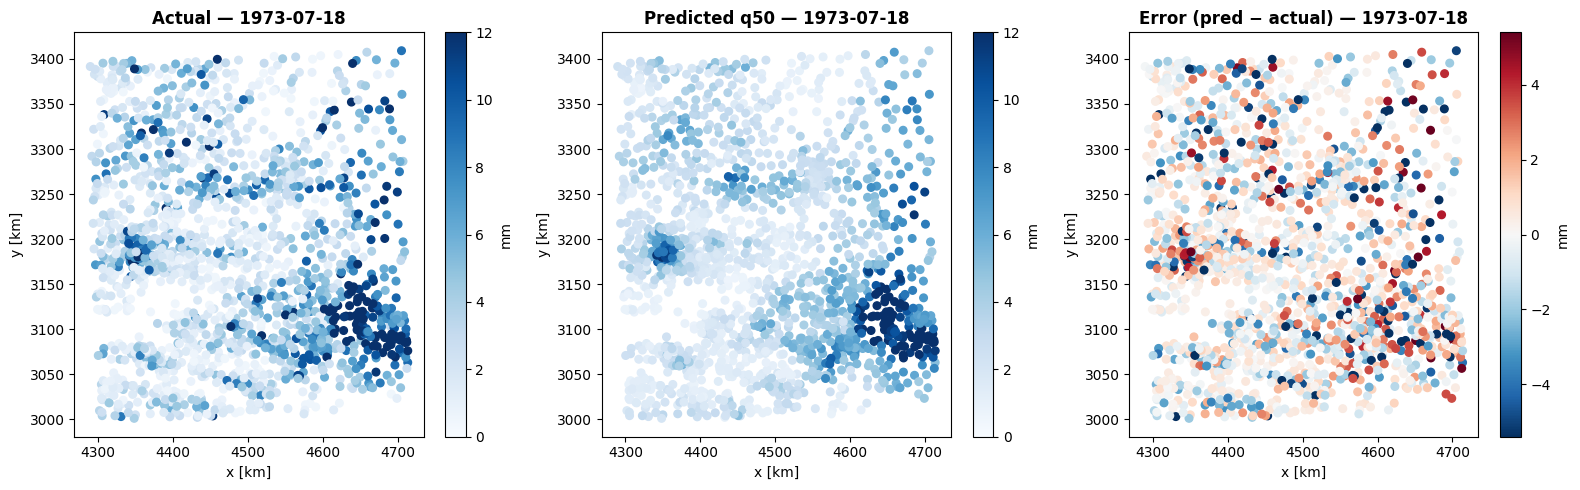


1973-07-18:  n=1570  CRPS=1.288  MAE=1.727  bias=-0.371 mm


In [29]:
day_counts   = df_all.groupby('date')['station_id'].count()
example_date = day_counts[day_counts > 100].sample(1, random_state=42).index[0]
print(f'Example date: {example_date}')

df_day = df_all[df_all['date'] == example_date].copy()
vmax   = df_day['precip_mm'].quantile(0.95)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sc0 = axes[0].scatter(
    df_day['x_proj'] / 1000, df_day['y_proj'] / 1000,
    c=df_day['precip_mm'], cmap='Blues', s=30, vmin=0, vmax=vmax)
plt.colorbar(sc0, ax=axes[0], label='mm')
axes[0].set_title(f'Actual — {example_date}', fontweight='bold')

sc1 = axes[1].scatter(
    df_day['x_proj'] / 1000, df_day['y_proj'] / 1000,
    c=df_day['q50'], cmap='Blues', s=30, vmin=0, vmax=vmax)
plt.colorbar(sc1, ax=axes[1], label='mm')
axes[1].set_title(f'Predicted q50 — {example_date}', fontweight='bold')

vmax_err = df_day['error'].abs().quantile(0.95)
sc2 = axes[2].scatter(
    df_day['x_proj'] / 1000, df_day['y_proj'] / 1000,
    c=df_day['error'], cmap='RdBu_r', s=30,
    vmin=-vmax_err, vmax=vmax_err)
plt.colorbar(sc2, ax=axes[2], label='mm')
axes[2].set_title(f'Error (pred − actual) — {example_date}', fontweight='bold')

for ax in axes:
    ax.set_xlabel('x [km]')
    ax.set_ylabel('y [km]')

fig.tight_layout()
plt.savefig(FIG_DIR / f'example_day_{example_date}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{example_date}:  n={len(df_day)}  '
        f'CRPS={df_day["crps"].mean():.3f}  '
        f'MAE={df_day["error"].abs().mean():.3f}  '
        f'bias={df_day["error"].mean():+.3f} mm')